### Part 1: Data Preparation

#### 1. Loading the Iris dataset and performing exploratory data analysis

In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Iris dataset
iris = load_iris()
x = iris.data
y = iris.target

# Creating a Dataframe for easier EDA
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = iris.target_names[y]

print(f"Features (x) shape: {x.shape}")
print(f"Target (y) shape: {y.shape}")

display(df.head())

print("\nDataset Information:")
df.info()
df['species'].unique()

Features (x) shape: (150, 4)
Target (y) shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


array(['setosa', 'versicolor', 'virginica'], dtype=object)

#### 2. Visualize feature distributions using histograms and pair plots

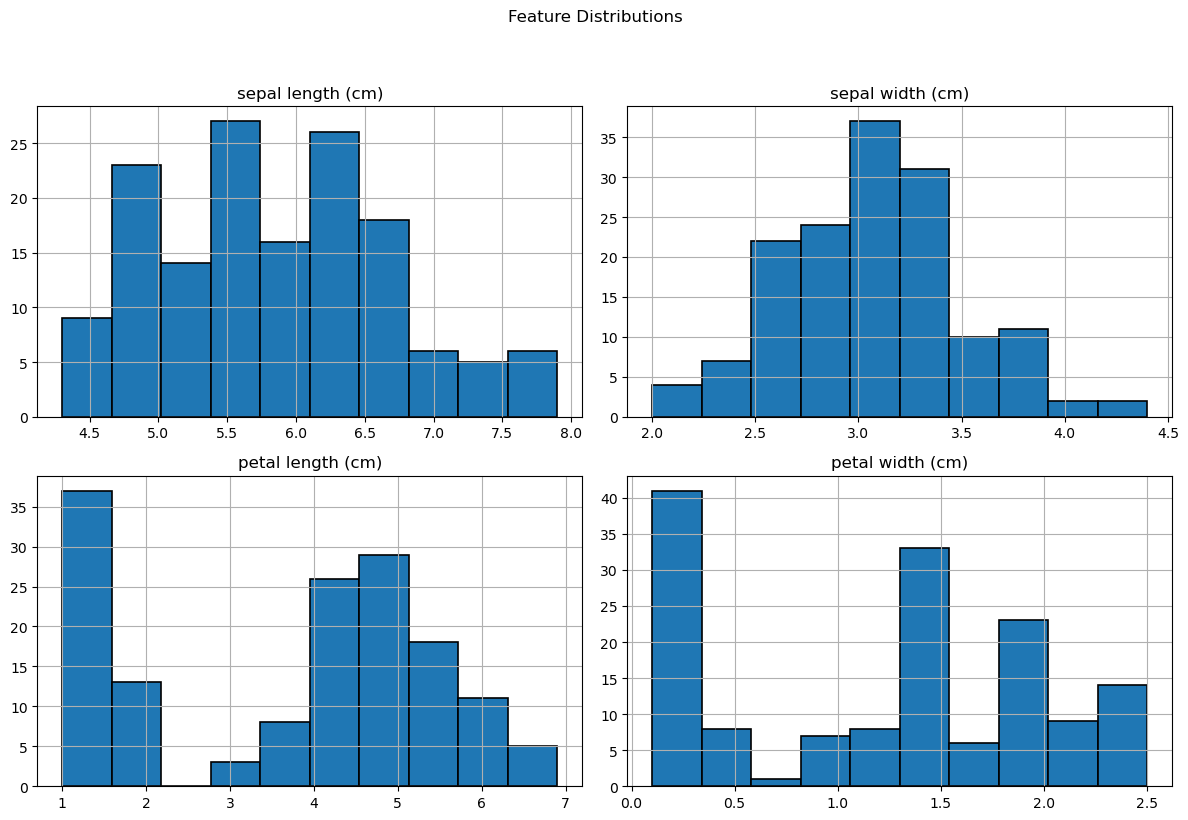

In [13]:
# Histograms for each feature
df.hist(edgecolor='black', linewidth=1.2, figsize=(12, 8))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

<Figure size 1000x800 with 0 Axes>

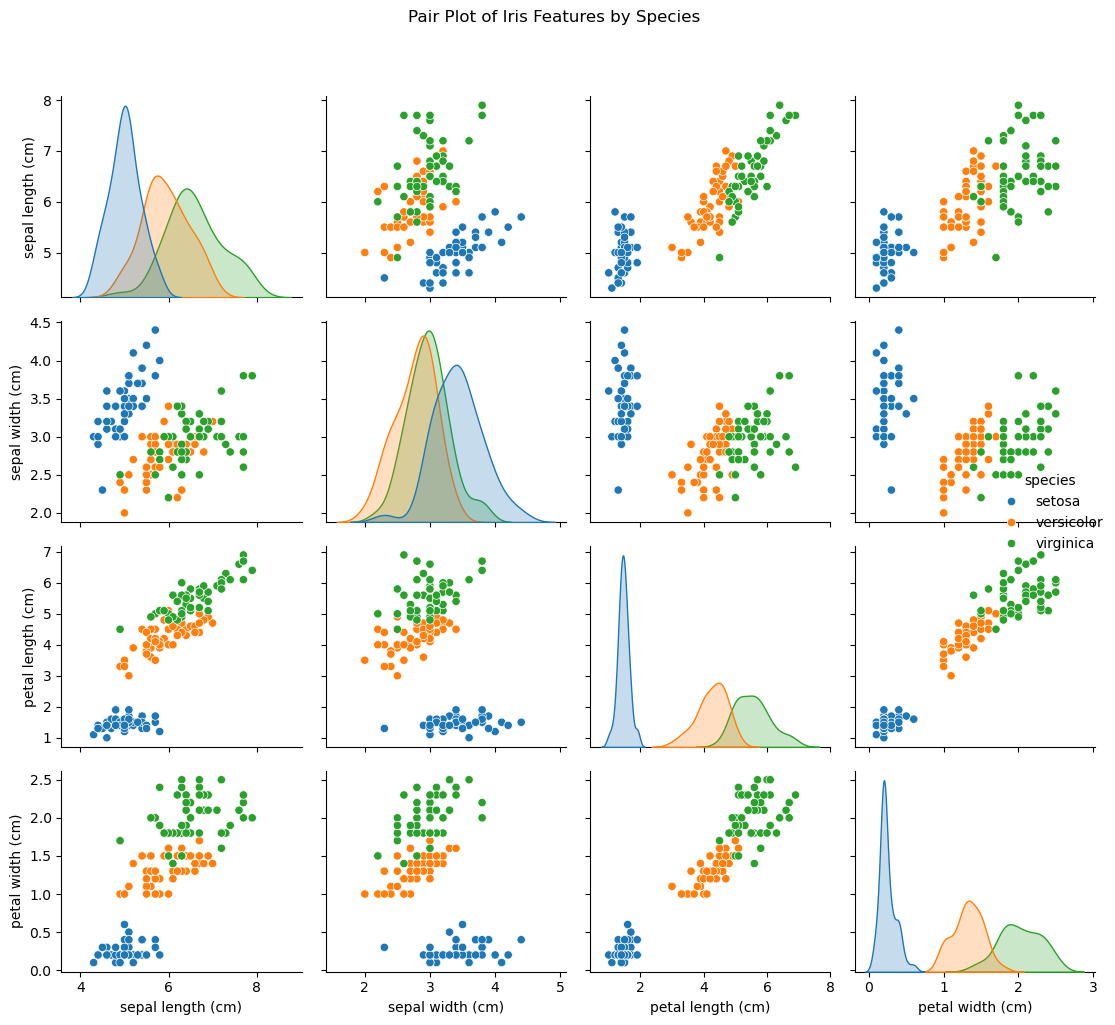

In [14]:
# Pair Plot to visualize relationships between features and species
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#### 3. Split the dataset into training (70%), validation (15%), and test (15%) sets

In [15]:
from sklearn.model_selection import train_test_split

# Splitign into training (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y)

# Spliting temp (30%) into validation (15%) and test (15%)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (105, 4), y_train shape: (105,)
x_val shape: (22, 4), y_val shape: (22,)
x_test shape: (23, 4), y_test shape: (23,)


#### 4. Normalize/standardize features using z-score normalization

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fitting on training data and transforming all splits
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

print("Features normalized using StandardScaler.")
print("First 5 rows of x_train_scaled:")
display(x_train_scaled[:5])
print("First 5 rows of x_val_scaled:")
display(x_val_scaled[:5])
print("First 5 rows of x_test_scaled:")
display(x_test_scaled[:5])

Features normalized using StandardScaler.
First 5 rows of x_train_scaled:


array([[-0.90045861, -1.22024754, -0.4419858 , -0.13661044],
       [ 0.38036614, -1.87955796,  0.40282929,  0.38029394],
       [-0.90045861,  1.63676428, -1.2868009 , -1.17041921],
       [ 1.07899781,  0.31814344,  1.19132338,  1.41410271],
       [-0.20182693, -0.56093712,  0.17754527,  0.12184175]])

First 5 rows of x_val_scaled:


array([[ 0.9625592 , -0.12139684,  0.68443432,  0.63874613],
       [ 0.61324336, -0.78070726,  0.85339734,  0.89719832],
       [-0.31826554, -1.22024754,  0.06490325, -0.13661044],
       [ 0.49680475, -0.56093712,  0.74075533,  0.38029394],
       [ 1.19543642,  0.0983733 ,  0.74075533,  1.41410271]])

First 5 rows of x_test_scaled:


array([[-0.20182693,  1.63676428, -1.17415888, -1.17041921],
       [-1.7155289 , -0.12139684, -1.39944291, -1.29964531],
       [ 0.26392752, -1.0004774 ,  1.02236036,  0.25106784],
       [-1.13333583, -1.44001768, -0.27302278, -0.26583654],
       [ 0.26392752, -0.12139684,  0.62811332,  0.76797223]])

#### 5. Convert labels to one-hot encoded vectors

In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

# Reshaping y to be 2D for OneHotEncoder
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_val_onehot = encoder.transform(y_val.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print("Labels converted to one-hot encoded vectors.")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"y_val_onehot shape: {y_val_onehot.shape}")
print(f"y_test_onehot shape: {y_test_onehot.shape}")

print("\nFirst 5 rows of y_train_onehot:")
display(y_train_onehot[:5])

Labels converted to one-hot encoded vectors.
y_train_onehot shape: (105, 3)
y_val_onehot shape: (22, 3)
y_test_onehot shape: (23, 3)

First 5 rows of y_train_onehot:


array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

### Part 2: Neural Network Implementation

#### 1. Initialize Network Architecture

o Input layer: 4 neurons (features)

o Hidden layer 1: 8 neurons with sigmoid activation

o Hidden layer 2: 6 neurons with sigmoid activation

o Output layer: 3 neurons with softmax activation

In [18]:
input_size = x_train_scaled.shape[1] # Number of features
hidden_layer1_size = 8
hidden_layer2_size = 6
output_size = y_train_onehot.shape[1] # Number of classes

print(f"Input Layer Size: {input_size}")
print(f"Hidden Layer 1 Size: {hidden_layer1_size}")
print(f"Hidden Layer 2 Size: {hidden_layer2_size}")
print(f"Output Layer Size: {output_size}")

Input Layer Size: 4
Hidden Layer 1 Size: 8
Hidden Layer 2 Size: 6
Output Layer Size: 3


#### 2. Implement Core Functions

o initialize_parameters(): Random weight initialization with proper scaling

o sigmoid() and sigmoid_derivative(): Activation functions

o softmax(): Output layer activation

o forward_propagation(): Compute activations layer by layer

o compute_loss(): Cross-entropy loss function

o backward_propagation(): Compute gradients using chain rule

o update_parameters(): Gradient descent update rule

In [19]:
def initialize_parameters(input_dim, hiddenl1_dim, hiddenl2_dim, output_dim):     #Initializes weights and biases with random values, adapting for one or two hidden layers
    np.random.seed(42)
    parameters = {
        'W1': np.random.randn(hiddenl1_dim, input_dim) * 0.01,
        'b1': np.zeros((hiddenl1_dim, 1)),
    }

    if hiddenl2_dim is not None and hiddenl2_dim > 0:
        # for 2 hidden layers
        parameters['W2'] = np.random.randn(hiddenl2_dim, hiddenl1_dim) * 0.01
        parameters['b2'] = np.zeros((hiddenl2_dim, 1))
        parameters['W3'] = np.random.randn(output_dim, hiddenl2_dim) * 0.01
        parameters['b3'] = np.zeros((output_dim, 1))
    else:
        # for 1 hidden layer (hiddenl1_dim directly connects to output)
        parameters['W2'] = np.random.randn(output_dim, hiddenl1_dim) * 0.01
        parameters['b2'] = np.zeros((output_dim, 1))

    return parameters

#Sigmoid activation function
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

#Derivative of the sigmoid function
def sigmoid_derivative(A):
    return A * (1 - A)

#ReLU activation function
def relu(Z):
    return np.maximum(0, Z)

#Derivative of the ReLU function
def relu_derivative(A):
    return (A > 0).astype(float)

#Tanh activation function
def tanh(Z):
    return np.tanh(Z)

#Derivative of the Tanh function
def tanh_derivative(A):
    return 1 - np.power(A, 2)

#Softmax activation function for the output layer
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True)) # for numerical stability
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

#Performs forward propagation through the network, adapting for one or two hidden layers
def forward_propagation(X, parameters, hidden_activation='sigmoid'):
    # Layer 1
    W1, b1 = parameters['W1'], parameters['b1']
    Z1 = np.dot(W1, X) + b1
    if hidden_activation == 'sigmoid':
        A1 = sigmoid(Z1)
    elif hidden_activation == 'relu':
        A1 = relu(Z1)
    elif hidden_activation == 'tanh':
        A1 = tanh(Z1)
    else:
        raise ValueError("Invalid hidden activation function")

    # Check if there is a second hidden layer
    if 'W3' in parameters: # Two hidden layers architecture
        W2, b2, W3, b3 = parameters['W2'], parameters['b2'], parameters['W3'], parameters['b3']
        Z2 = np.dot(W2, A1) + b2
        if hidden_activation == 'sigmoid':
            A2 = sigmoid(Z2)
        elif hidden_activation == 'relu':
            A2 = relu(Z2)
        elif hidden_activation == 'tanh':
            A2 = tanh(Z2)
        else:
            raise ValueError("Invalid hidden activation function")

        Z3 = np.dot(W3, A2) + b3
        A3 = softmax(Z3)
        cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
    else: # One hidden layer architecture
        W2, b2 = parameters['W2'], parameters['b2']
        Z2 = np.dot(W2, A1) + b2 # This Z2 is actually the output layer's pre-activation
        A2 = softmax(Z2) # This A2 is actually the output layer's activation
        A3 = A2 # For consistency with loss function and prediction
        cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A3': A3} # Only two layers in cache

    return A3, cache

#Computes the cross-entropy loss
def compute_loss(A3, Y):
    m = Y.shape[1]
    # Avoid log(0) by clipping A3 values
    A3_clipped = np.clip(A3, 1e-10, 1 - 1e-10)
    # Correctly index A3_clipped using the integer indices of the true class
    log_likelihood = -np.log(A3_clipped[np.argmax(Y, axis=0), np.arange(m)])
    loss = np.sum(log_likelihood) / m
    return loss

#Performs backward propagation to compute gradients, adapting for one or two hidden layers
def backward_propagation(X, Y, parameters, cache, hidden_activation='sigmoid'):
    m = X.shape[1]

    if 'W3' in parameters: # Two hidden layers architecture
        W1, b1, W2, b2, W3, b3 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2'], parameters['W3'], parameters['b3']
        A1, A2, A3 = cache['A1'], cache['A2'], cache['A3']

        # Output layer
        dZ3 = A3 - Y
        dW3 = np.dot(dZ3, A2.T) / m
        db3 = np.sum(dZ3, axis=1, keepdims=True) / m

        # Hidden layer 2
        dA2 = np.dot(W3.T, dZ3)
        if hidden_activation == 'sigmoid':
            dZ2 = dA2 * sigmoid_derivative(A2)
        elif hidden_activation == 'relu':
            dZ2 = dA2 * relu_derivative(A2)
        elif hidden_activation == 'tanh':
            dZ2 = dA2 * tanh_derivative(A2)
        else:
            raise ValueError("Invalid hidden activation function")
        dW2 = np.dot(dZ2, A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m

        # Hidden layer 1
        dA1 = np.dot(W2.T, dZ2)
        if hidden_activation == 'sigmoid':
            dZ1 = dA1 * sigmoid_derivative(A1)
        elif hidden_activation == 'relu':
            dZ1 = dA1 * relu_derivative(A1)
        elif hidden_activation == 'tanh':
            dZ1 = dA1 * tanh_derivative(A1)
        else:
            raise ValueError("Invalid hidden activation function")
        dW1 = np.dot(dZ1, X.T) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        gradients = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2, 'dW3': dW3, 'db3': db3}

    else: # One hidden layer architecture
        W1, b1, W2, b2 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2']
        A1, A3 = cache['A1'], cache['A3']

        # Output layer (this corresponds to the 'W2', 'b2' of a two-layer network)
        dZ2 = A3 - Y # This is dZ_output
        dW2 = np.dot(dZ2, A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m

        # Hidden layer 1
        dA1 = np.dot(W2.T, dZ2)
        if hidden_activation == 'sigmoid':
            dZ1 = dA1 * sigmoid_derivative(A1)
        elif hidden_activation == 'relu':
            dZ1 = dA1 * relu_derivative(A1)
        elif hidden_activation == 'tanh':
            dZ1 = dA1 * tanh_derivative(A1)
        else:
            raise ValueError("Invalid hidden activation function")
        dW1 = np.dot(dZ1, X.T) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        gradients = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2} # Only two sets of gradients

    return gradients

#Updates network parameters using gradient descent
def update_parameters(parameters, gradients, learning_rate):
    for key in parameters:
        if key.startswith('W'):
            parameters[key] -= learning_rate * gradients[f'd{key}']
        elif key.startswith('b'):
            parameters[key] -= learning_rate * gradients[f'd{key}']
    return parameters

#Predicts the output class for given input X
def predict(X, parameters, hidden_activation='sigmoid'):
    A3, _ = forward_propagation(X, parameters, hidden_activation)
    predictions = np.argmax(A3, axis=0)
    return predictions

#Calculates the accuracy of predictions
def calculate_accuracy(predictions, labels):
    return np.mean(predictions == labels) * 100

print("Core functions (initialize_parameters,sigmoid,sigmoid_derivative,softmax,forward_propagation,compute_loss, backward_propagation,update_parameters,predict,calculate_accuracy) defined with architecture flexibility.")

Core functions (initialize_parameters,sigmoid,sigmoid_derivative,softmax,forward_propagation,compute_loss, backward_propagation,update_parameters,predict,calculate_accuracy) defined with architecture flexibility.


#### 3. Training Loop

o Implement mini-batch gradient descent (batch size: 16)

o Train for 1000 epochs with learning rate = 0.01

o Track and store training loss and validation accuracy every 50 epochs

o Implement early stopping if validation accuracy plateaus

In [20]:
import pickle

def save_parameters(parameters, filename):
    """Saves the model parameters to a file."""
    with open(filename, 'wb') as f:
        pickle.dump(parameters, f)
    print(f"Parameters saved to {filename}")

def load_parameters(filename):
    """Loads the model parameters from a file."""
    with open(filename, 'rb') as f:
        parameters = pickle.load(f)
    print(f"Parameters loaded from {filename}")
    return parameters

print("Save and load parameter functions defined.")

Save and load parameter functions defined.


In [21]:
def train_model(x_train, y_train_onehot, y_train_labels, x_val, y_val_onehot, y_val_labels,
                input_size, hidden_layer1_size, hidden_layer2_size, output_size,
                learning_rate=0.01, epochs=1000, batch_size=16, hidden_activation='sigmoid',
                print_cost=True, early_stopping_patience=10):

    parameters = initialize_parameters(input_size, hidden_layer1_size, hidden_layer2_size, output_size)
    costs = []
    train_accuracies = []
    val_accuracies = []
    best_val_accuracy = 0
    epochs_no_improve = 0
    best_parameters = parameters.copy()

    m_train = x_train.shape[1] # Number of training examples

    # The train_model expects (n_features, m_samples) for X and (n_classes, m_samples) for y_onehot
    # and (m_samples,) for y_labels
    x_train_transposed = x_train
    y_train_onehot_transposed = y_train_onehot

    x_val_transposed = x_val
    y_val_onehot_transposed = y_val_onehot

    for epoch in range(1, epochs + 1):
        # Shuffling the training data for each epoch
        permutation = np.random.permutation(m_train)
        shuffled_x = x_train_transposed[:, permutation]
        shuffled_y_onehot = y_train_onehot_transposed[:, permutation]
        shuffled_y_labels = y_train_labels[permutation]

        epoch_cost = 0
        num_batches = int(np.ceil(m_train / batch_size))

        for i in range(num_batches):
            start = i * batch_size
            end = min((i + 1) * batch_size, m_train)
            x_batch = shuffled_x[:, start:end]
            y_batch_onehot = shuffled_y_onehot[:, start:end]
            y_batch_labels = shuffled_y_labels[start:end]

            # Forward propagation
            A3, cache = forward_propagation(x_batch, parameters, hidden_activation)

            # Computing loss
            cost = compute_loss(A3, y_batch_onehot)
            epoch_cost += cost

            # Backward propagation
            gradients = backward_propagation(x_batch, y_batch_onehot, parameters, cache, hidden_activation)

            # Updating parameters
            parameters = update_parameters(parameters, gradients, learning_rate)

        epoch_cost /= num_batches

        # Storing costs and accuracies every 50 epochs
        if epoch % 50 == 0 or epoch == 1:
            # Training accuracy
            train_preds = predict(x_train_transposed, parameters, hidden_activation)
            train_acc = calculate_accuracy(train_preds, y_train_labels)

            # Validation accuracy
            val_preds = predict(x_val_transposed, parameters, hidden_activation)
            val_acc = calculate_accuracy(val_preds, y_val_labels)

            costs.append(epoch_cost)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)

            if print_cost:
                print(f"Epoch {epoch}, Cost: {epoch_cost:.4f}, Train Accuracy: {train_acc:.2f}%, Val Accuracy: {val_acc:.2f}%")

            # Early stopping check
            if val_acc > best_val_accuracy:
                best_val_accuracy = val_acc
                epochs_no_improve = 0
                best_parameters = parameters.copy()
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience and epoch > 100: # Don't stop too early
                    print(f"Early stopping triggered at epoch {epoch} due to no improvement in validation accuracy for {early_stopping_patience} epochs.")
                    parameters = best_parameters # Revert to best parameters
                    break

    return parameters, costs, train_accuracies, val_accuracies, epoch


# Initializing parameters and starting training with original architecture
# Note: x_train_scaled and y_train_onehot should be transposed to (n_features, m_samples) and (n_classes, m_samples) respectively for consistency with implementation

# Transposing if not already in the correct shape (n_features, m_samples)
x_train_t = x_train_scaled.T
y_train_onehot_t = y_train_onehot.T
y_val_onehot_t = y_val_onehot.T
x_val_t = x_val_scaled.T
x_test_t = x_test_scaled.T

# Getting original y labels for accuracy calculation
y_train_labels = np.argmax(y_train_onehot_t, axis=0)
y_val_labels = np.argmax(y_val_onehot_t, axis=0)
y_test_labels = np.argmax(y_test_onehot, axis=1) # y_test_onehot is already (m_samples, n_classes)

print("Training the model with initial architecture (4-8-6-3, sigmoid activation) and learning rate 0.01")
parameters_mlp, costs_mlp, train_accuracies_mlp, val_accuracies_mlp, epochs_ran_mlp = \
    train_model(x_train_t, y_train_onehot_t, y_train_labels, x_val_t, y_val_onehot_t, y_val_labels,
                input_size, hidden_layer1_size, hidden_layer2_size, output_size,
                learning_rate=0.01, epochs=1000, batch_size=16, hidden_activation='sigmoid',
                early_stopping_patience=20)

print(f"\nTraining complete after {epochs_ran_mlp} epochs.")

# Save the trained parameters
save_parameters(parameters_mlp, 'initial_mlp_parameters.pkl')

# Evaluate on test set
y_pred_mlp = predict(x_test_t, parameters_mlp, hidden_activation='sigmoid')
test_accuracy_mlp = calculate_accuracy(y_pred_mlp, y_test_labels)
print(f"Test Accuracy (Original MLP): {test_accuracy_mlp:.2f}%")

Training the model with initial architecture (4-8-6-3, sigmoid activation) and learning rate 0.01
Epoch 1, Cost: 1.0992, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 50, Cost: 1.0990, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 100, Cost: 1.0995, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 150, Cost: 1.0993, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 200, Cost: 1.0993, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 250, Cost: 1.0992, Train Accuracy: 33.33%, Val Accuracy: 36.36%
Epoch 300, Cost: 1.0989, Train Accuracy: 33.33%, Val Accuracy: 36.36%
Epoch 350, Cost: 1.0990, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 400, Cost: 1.0992, Train Accuracy: 33.33%, Val Accuracy: 36.36%
Epoch 450, Cost: 1.0990, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 500, Cost: 1.0991, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 550, Cost: 1.0991, Train Accuracy: 33.33%, Val Accuracy: 36.36%
Epoch 600, Cost: 1.0988, Train Accuracy: 33.33%, Val Accuracy: 31

### Part 3: Evaluation and Analysis

#### 1. Test the trained model on the test set
#### 2. Generate confusion matrix and classification report


Confusion Matrix (Original MLP):
 [[0 0 7]
 [0 0 8]
 [0 0 8]]

Classification Report (Original MLP):
               precision    recall  f1-score   support

      setosa       0.00      0.00      0.00         7
  versicolor       0.00      0.00      0.00         8
   virginica       0.35      1.00      0.52         8

    accuracy                           0.35        23
   macro avg       0.12      0.33      0.17        23
weighted avg       0.12      0.35      0.18        23



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


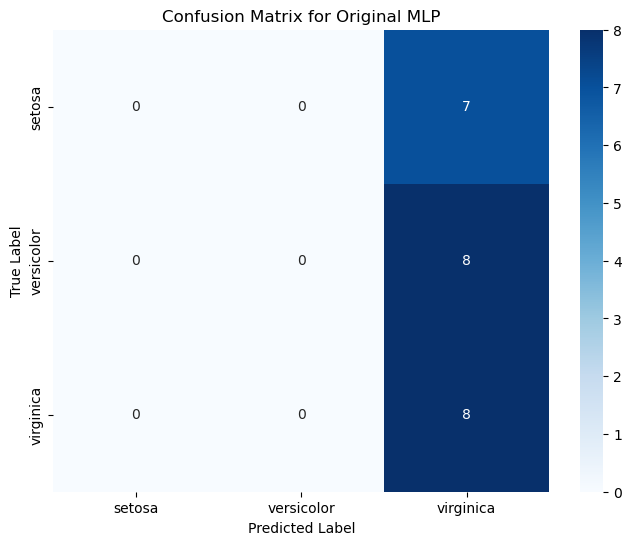

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
conf_matrix_mlp = confusion_matrix(y_test_labels, y_pred_mlp)
print("\nConfusion Matrix (Original MLP):\n", conf_matrix_mlp)

# Classification Report
class_report_mlp = classification_report(y_test_labels, y_pred_mlp, target_names=iris.target_names)
print("\nClassification Report (Original MLP):\n", class_report_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Original MLP')
plt.show()

#### 3. Visualize decision boundaries (use PCA for 2D projection)

In [23]:
from sklearn.decomposition import PCA

# Applying PCA to reduce dimensionality to 2 for visualization
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)
x_val_pca = pca.transform(x_val_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("PCA applied. Explained variance ratio:", pca.explained_variance_ratio_)
print(f"x_train_pca shape: {x_train_pca.shape}")
print(f"x_val_pca shape: {x_val_pca.shape}")
print(f"x_test_pca shape: {x_test_pca.shape}")

# Retraining a simplified MLP model on the 2D PCA data
input_size_pca = x_train_pca.shape[1]
hidden_layer1_size_pca = 8 # Can be adjusted
output_size_pca = y_train_onehot.shape[1] # Still 3 classes

# Transposing PCA data for consistency with Neural Network implementation
x_train_pca_t = x_train_pca.T
x_val_pca_t = x_val_pca.T

print("\nTraining MLP on 2D PCA data")
parameters_pca, costs_pca, train_accuracies_pca, val_accuracies_pca, epochs_ran_pca = \
    train_model(x_train_pca_t, y_train_onehot_t, y_train_labels, x_val_pca_t, y_val_onehot_t, y_val_labels,
                input_size_pca, hidden_layer1_size_pca, hidden_layer2_size=None, output_size=output_size_pca,
                learning_rate=0.01, epochs=1000, batch_size=16, hidden_activation='sigmoid',
                early_stopping_patience=20)

print(f"\nTraining complete for PCA model after {epochs_ran_pca} epochs.")

y_pred_pca = predict(x_test_pca.T, parameters_pca, hidden_activation='sigmoid')
test_accuracy_pca = calculate_accuracy(y_pred_pca, y_test_labels)
print(f"Test Accuracy (MLP with PCA): {test_accuracy_pca:.2f}%")

save_parameters(parameters_mlp, 'initial_(mlp_with_pca)_parameters.pkl')

PCA applied. Explained variance ratio: [0.7264421  0.23378786]
x_train_pca shape: (105, 2)
x_val_pca shape: (22, 2)
x_test_pca shape: (23, 2)

Training MLP on 2D PCA data
Epoch 1, Cost: 1.0990, Train Accuracy: 33.33%, Val Accuracy: 31.82%
Epoch 50, Cost: 1.0992, Train Accuracy: 63.81%, Val Accuracy: 63.64%
Epoch 100, Cost: 1.0974, Train Accuracy: 67.62%, Val Accuracy: 72.73%
Epoch 150, Cost: 1.0895, Train Accuracy: 66.67%, Val Accuracy: 68.18%
Epoch 200, Cost: 1.0521, Train Accuracy: 66.67%, Val Accuracy: 68.18%
Epoch 250, Cost: 0.9339, Train Accuracy: 72.38%, Val Accuracy: 72.73%
Epoch 300, Cost: 0.7524, Train Accuracy: 80.95%, Val Accuracy: 77.27%
Epoch 350, Cost: 0.6185, Train Accuracy: 84.76%, Val Accuracy: 86.36%
Epoch 400, Cost: 0.5324, Train Accuracy: 88.57%, Val Accuracy: 86.36%
Epoch 450, Cost: 0.4905, Train Accuracy: 90.48%, Val Accuracy: 86.36%
Epoch 500, Cost: 0.4411, Train Accuracy: 91.43%, Val Accuracy: 90.91%
Epoch 550, Cost: 0.4165, Train Accuracy: 91.43%, Val Accuracy:

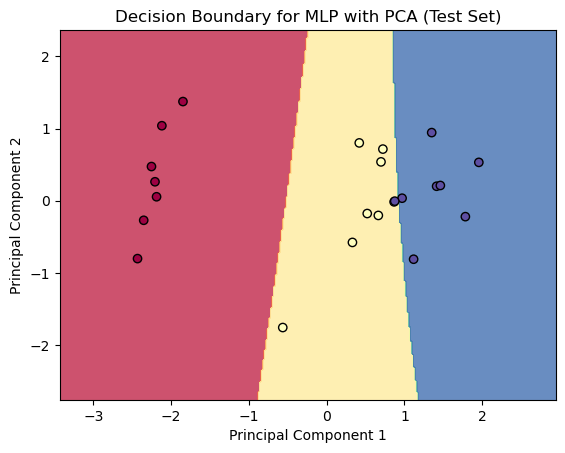

In [24]:
# Plotting decision boundaries
def plot_decision_boundary(X, y, parameters, activation_fn, title="Decision Boundary"):
    # Setting min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.02 # step size in the mesh

    # Generating a meshgrid of points with the step size h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predicting the function value for the whole grid
    Z = predict(np.c_[xx.ravel(), yy.ravel()].T, parameters, activation_fn)
    Z = Z.reshape(xx.shape)

    # Plotting the contour and the examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral, edgecolor='k')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

# Plotting decision boundary for the PCA-trained model
plot_decision_boundary(x_test_pca.T, y_test_labels, parameters_pca, 'sigmoid', "Decision Boundary for MLP with PCA (Test Set)")

#### 4. Compare performance with sklearn's MLPClassifier

Test Accuracy (Scikit-learn MLPClassifier): 34.78%

Confusion Matrix (Scikit-learn MLPClassifier):
 [[0 7 0]
 [0 8 0]
 [0 8 0]]

Classification Report (Scikit-learn MLPClassifier):
               precision    recall  f1-score   support

      setosa       0.00      0.00      0.00         7
  versicolor       0.35      1.00      0.52         8
   virginica       0.00      0.00      0.00         8

    accuracy                           0.35        23
   macro avg       0.12      0.33      0.17        23
weighted avg       0.12      0.35      0.18        23



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


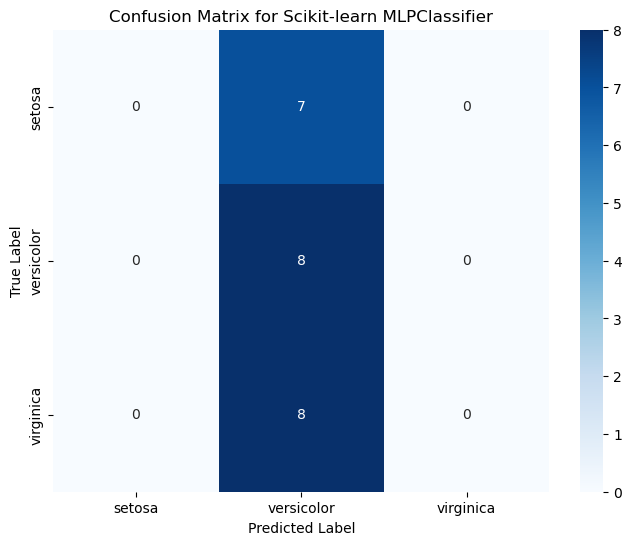

In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Initializing and training Scikit-learn's MLPClassifier
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(8, 6), activation='logistic', solver='sgd',
                            learning_rate_init=0.01, max_iter=1000, random_state=42,
                            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20)

# Note: sklearn's MLPClassifier expects (n_samples, n_features) and (n_samples,) for labels
sklearn_mlp.fit(x_train_scaled, y_train)

# Predictiing on the test set
y_pred_sklearn = sklearn_mlp.predict(x_test_scaled)

# Calculating accuracy
test_accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn) * 100
print(f"Test Accuracy (Scikit-learn MLPClassifier): {test_accuracy_sklearn:.2f}%")

# Confusion Matrix
conf_matrix_sklearn = confusion_matrix(y_test, y_pred_sklearn)
print("\nConfusion Matrix (Scikit-learn MLPClassifier):\n", conf_matrix_sklearn)

# Classification Report
class_report_sklearn = classification_report(y_test, y_pred_sklearn, target_names=iris.target_names)
print("\nClassification Report (Scikit-learn MLPClassifier):\n", class_report_sklearn)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_sklearn, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Scikit-learn MLPClassifier')
plt.show()